In [ ]:
# DATASET
# https://drive.google.com/file/d/1NsMbLVI1dedophFQS0x1NZU_2BsSjJlt/view?usp=sharing

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("dados_sobre_casas.csv")

In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
df.head()

,salario_medio_moradores_regiao,idade_media_casas_regiao,quantidade_media_comodos_regiao,quantidade_media_quartos_regiao,populacao_regiao,valor_casa
0,79545,5,7,4,23086,1059034
1,79248,6,6,3,40173,1505891
2,61287,5,8,5,36882,1058988
3,63345,7,5,3,34310,1260617
4,59982,5,7,4,26354,630943


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   salario_medio_moradores_regiao   5000 non-null   int64
 1   idade_media_casas_regiao         5000 non-null   int64
 2   quantidade_media_comodos_regiao  5000 non-null   int64
 3   quantidade_media_quartos_regiao  5000 non-null   int64
 4   populacao_regiao                 5000 non-null   int64
 5   valor_casa                       5000 non-null   int64
dtypes: int64(6)
memory usage: 234.5 KB


<Axes: ylabel='Frequency'>

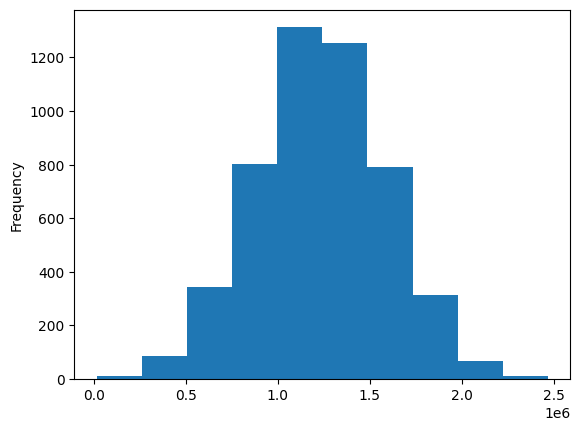

In [10]:
df["valor_casa"].plot(kind="hist")

In [12]:
df["valor_casa"].describe().astype(str)

,valor_casa
count,5000.0
mean,1232072.6578
std,353117.62499479245
min,15939.0
25%,997577.5
50%,1232669.0
75%,1471210.0
max,2469066.0


<Axes: >

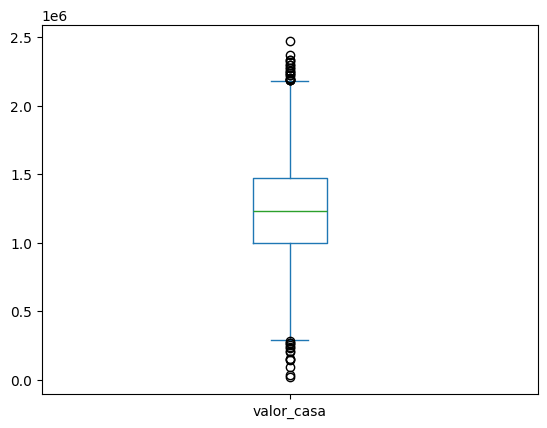

In [13]:
df["valor_casa"].plot(kind="box")

<Axes: ylabel='Frequency'>

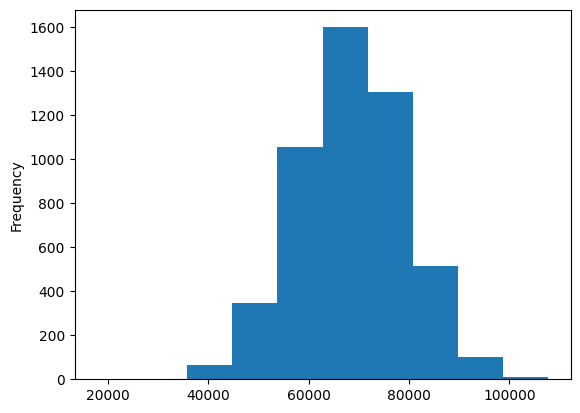

In [14]:
df["salario_medio_moradores_regiao"].plot(kind="hist")

<Axes: >

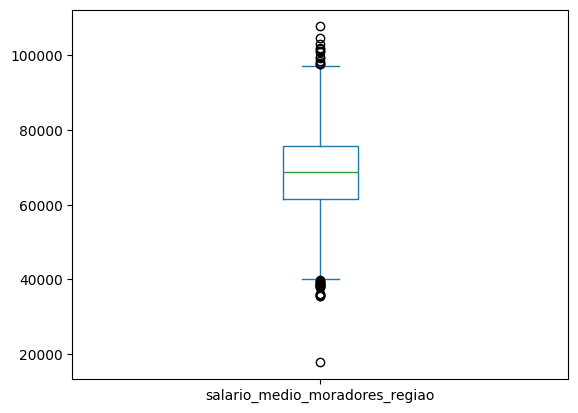

In [15]:
df["salario_medio_moradores_regiao"].plot(kind="box")

<Axes: xlabel='salario_medio_moradores_regiao', ylabel='valor_casa'>

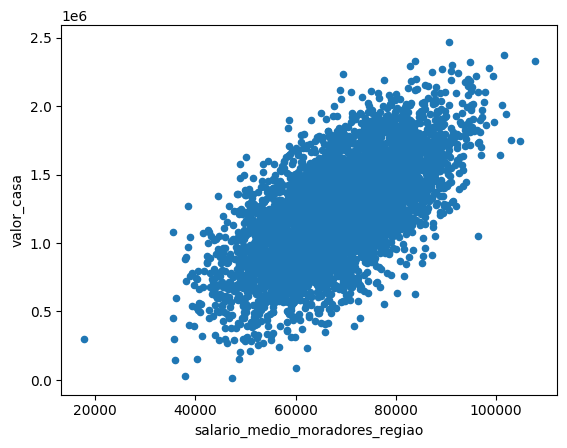

In [16]:
df.plot(kind="scatter", x="salario_medio_moradores_regiao", y="valor_casa")

<Axes: xlabel='populacao_regiao', ylabel='valor_casa'>

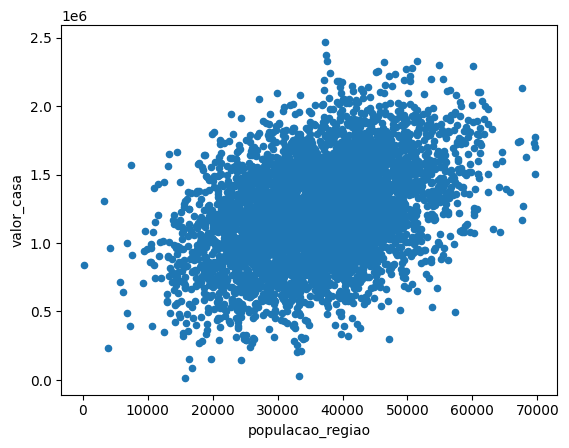

In [17]:
df.plot(kind="scatter", x="populacao_regiao", y="valor_casa")

<Axes: xlabel='salario_medio_moradores_regiao', ylabel='valor_casa'>

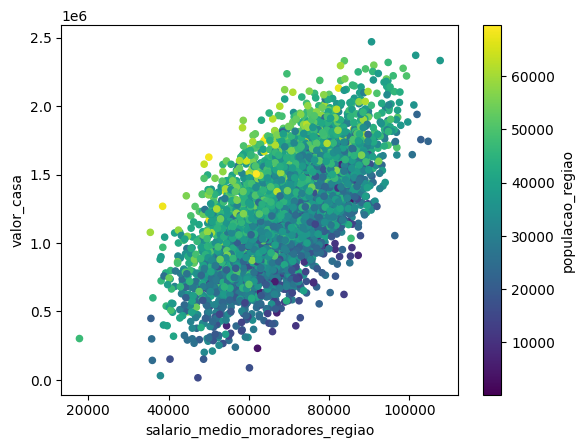

In [19]:
df.plot(kind="scatter", x="salario_medio_moradores_regiao", y="valor_casa", c="populacao_regiao", colormap="viridis")

In [20]:
import seaborn as sns

In [27]:
correlacao = df.corr()

correlacao

,salario_medio_moradores_regiao,idade_media_casas_regiao,quantidade_media_comodos_regiao,quantidade_media_quartos_regiao,populacao_regiao,valor_casa
salario_medio_moradores_regiao,1.000000,0.003024,-0.008977,0.018764,-0.016234,0.639734
idade_media_casas_regiao,0.003024,1.000000,-0.005487,0.010348,-0.014630,0.439171
quantidade_media_comodos_regiao,-0.008977,-0.005487,1.000000,0.487542,-0.001001,0.325114
quantidade_media_quartos_regiao,0.018764,0.010348,0.487542,1.000000,-0.020778,0.172429
populacao_regiao,-0.016234,-0.014630,-0.001001,-0.020778,1.000000,0.408556
valor_casa,0.639734,0.439171,0.325114,0.172429,0.408556,1.000000


<Axes: >

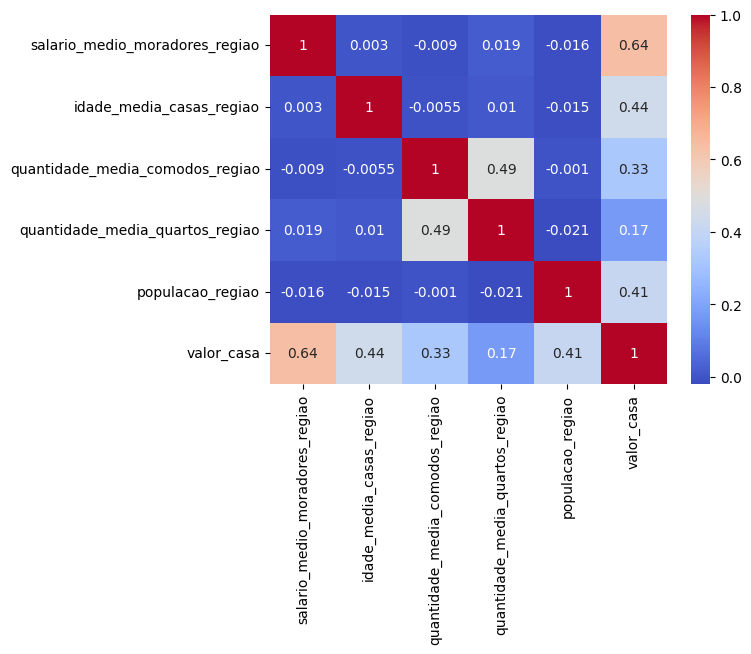

In [31]:
sns.heatmap(correlacao, annot=True, cmap="coolwarm")

In [32]:
X = df.drop(columns=["valor_casa"])

y = df["valor_casa"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
X_train.shape

(4000, 5)

In [42]:
X_test.shape

(1000, 5)

In [43]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()

model_1.fit(X_train, y_train)

LinearRegression()

In [44]:
model_1.intercept_

np.float64(-2345406.559263501)

In [45]:
model_1.coef_

array([2.15626290e+01, 1.50590200e+05, 1.10584886e+05, 1.64449809e+03,
       1.51725318e+01])

In [46]:
X_train.head(1)

,salario_medio_moradores_regiao,idade_media_casas_regiao,quantidade_media_comodos_regiao,quantidade_media_quartos_regiao,populacao_regiao
4227,66547,5,6,4,27850


In [47]:
y_train.head(1)

,valor_casa
4227,1094880


In [48]:
a = 66547
b = 5
c = 6
d = 4
e = 27850

teste = [a, b, c, d, e]

model_1.predict([teste])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([935115.02823646])

In [ ]:
# valor real =     1094880
# valor predito =   935115

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


predicoes = model_1.predict(X_test)

In [51]:
r2_score(y_test, predicoes)

0.8892448945202103

In [52]:
mean_absolute_error(y_test, predicoes)

93564.18067602196

In [53]:
mean_absolute_percentage_error(y_test, predicoes)

0.08575122090340062

In [54]:
mean_squared_error(y_test, predicoes)

13626473635.029047

### Selecione um modelo de regressão e compare os resultados